# 10. CO2KostAufG — Landlord Carbon Cost-Sharing Analysis

**What:** Since January 2023, German landlords share CO2 costs with tenants based on building energy efficiency. The worse the building, the more the landlord pays (up to 90%).

**Why it matters for RentSignal:** This is a hidden cost that directly reduces net rental income. Our dataset has `thermalChar` (kWh/m²/year) for all 10,275 listings — we can derive energy classes and calculate the CO2 cost exposure for every apartment in Berlin.

**The Comply pillar expansion:** Mietpreisbremse tells you the legal maximum rent. CO2KostAufG tells you the hidden cost eating into that rent. Together = complete compliance picture.

**Source:** CO2KostAufG (Kohlendioxidkostenaufteilungsgesetz), in force since 1 January 2023.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load dataset
df = pd.read_parquet("../data/processed/listings_clean.parquet")
print(f"Loaded {len(df):,} Berlin listings")
print(f"\nthermalChar (kWh/m²/year) stats:")
print(df["thermalChar"].describe().round(1))
print(f"\nheatingType distribution:")
print(df["heatingType"].value_counts())

Loaded 10,275 Berlin listings

thermalChar (kWh/m²/year) stats:
count    10275.0
mean       109.4
std         44.5
min          0.5
25%         86.0
50%        105.0
75%        123.1
max       1555.0
Name: thermalChar, dtype: float64

heatingType distribution:
heatingType
central_heating                   4037
district_heating                  2025
unknown                           1458
floor_heating                     1183
self_contained_central_heating     788
gas_heating                        388
oil_heating                        154
combined_heat_and_power_plant      118
heat_pump                           48
night_storage_heater                35
wood_pellet_heating                 17
electric_heating                    16
solar_heating                        5
stove_heating                        3
Name: count, dtype: int64


## Step 1: Derive Energy Classes from thermalChar

The German Energieausweis (Energy Performance Certificate) classifies buildings by their energy consumption in kWh/m²/year. We derive this from our `thermalChar` column.

In [3]:
# Energy class boundaries (kWh/m²/year) per German Energieausweis
ENERGY_CLASS_BINS = [0, 30, 50, 75, 100, 130, 160, 200, 250, float("inf")]
ENERGY_CLASS_LABELS = ["A+", "A", "B", "C", "D", "E", "F", "G", "H"]

df["energy_class"] = pd.cut(
    df["thermalChar"],
    bins=ENERGY_CLASS_BINS,
    labels=ENERGY_CLASS_LABELS,
    right=True,
)

# Distribution
class_dist = df["energy_class"].value_counts().sort_index()
print("Energy class distribution:")
print(class_dist)
print(f"\nPercentages:")
print((class_dist / len(df) * 100).round(1))

Energy class distribution:
energy_class
A+      74
A      334
B     1494
C     1429
D     4733
E     1194
F      711
G      238
H       68
Name: count, dtype: int64

Percentages:
energy_class
A+     0.7
A      3.3
B     14.5
C     13.9
D     46.1
E     11.6
F      6.9
G      2.3
H      0.7
Name: count, dtype: float64


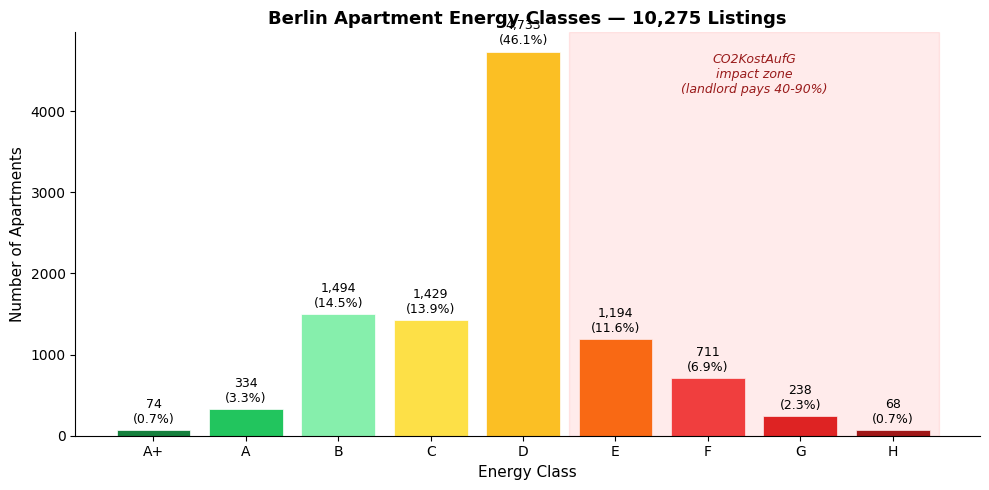

Saved: data/processed/energy_class_distribution.png


In [3]:
# Visualize energy class distribution
fig, ax = plt.subplots(figsize=(10, 5))

colors = {
    "A+": "#15803d", "A": "#22c55e", "B": "#86efac",
    "C": "#fde047", "D": "#fbbf24", "E": "#f97316",
    "F": "#ef4444", "G": "#dc2626", "H": "#991b1b",
}

bars = ax.bar(
    class_dist.index.astype(str),
    class_dist.values,
    color=[colors[c] for c in class_dist.index],
    edgecolor="white",
    linewidth=0.5,
)

# Add count + percentage labels
for bar, count in zip(bars, class_dist.values):
    pct = count / len(df) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{count:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_xlabel("Energy Class", fontsize=11)
ax.set_ylabel("Number of Apartments", fontsize=11)
ax.set_title("Berlin Apartment Energy Classes — 10,275 Listings", fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

# Add annotation about CO2 impact zone
ax.axvspan(4.5, 8.5, alpha=0.08, color="red")
ax.text(6.5, ax.get_ylim()[1] * 0.85, "CO2KostAufG\nimpact zone\n(landlord pays 40-90%)",
        ha="center", fontsize=9, color="#991b1b", fontstyle="italic")

plt.tight_layout()
plt.savefig("../data/processed/energy_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/processed/energy_class_distribution.png")

## Step 2: CO2KostAufG Cost-Sharing Rules

The law defines a 10-step sharing table based on building CO2 emissions (kg CO2/m²/year). We convert kWh to kg CO2 using standard emission factors per heating type.

In [4]:
# CO2 emission factors by heating type (kg CO2 per kWh)
# Source: UBA (Umweltbundesamt) 2024
EMISSION_FACTORS = {
    "gas_heating": 0.201,
    "central_heating": 0.201,          # assume gas as default
    "self_contained_central_heating": 0.201,
    "oil_heating": 0.266,
    "district_heating": 0.130,
    "combined_heat_and_power_plant": 0.130,
    "floor_heating": 0.201,            # assume gas
    "heat_pump": 0.045,                # electricity-based, very low
    "electric_heating": 0.420,          # direct electric = high
    "night_storage_heater": 0.420,
    "solar_heating": 0.020,
    "wood_pellet_heating": 0.023,
    "stove_heating": 0.266,            # assume oil/coal
    "unknown": 0.201,                  # assume gas as default
}

# Convert kWh/m²/year to kg CO2/m²/year
df["emission_factor"] = df["heatingType"].map(EMISSION_FACTORS).fillna(0.201)
df["co2_kg_per_sqm"] = df["thermalChar"] * df["emission_factor"]

print("CO2 emissions (kg CO2/m²/year) by heating type:")
print(df.groupby("heatingType")["co2_kg_per_sqm"].agg(["mean", "median", "count"]).round(1).sort_values("count", ascending=False))
print(f"\nOverall: mean={df['co2_kg_per_sqm'].mean():.1f}, median={df['co2_kg_per_sqm'].median():.1f} kg CO2/m²/year")

CO2 emissions (kg CO2/m²/year) by heating type:
                                mean  median  count
heatingType                                        
central_heating                 23.2    21.1   4037
district_heating                13.3    13.3   2025
unknown                         20.5    21.1   1458
floor_heating                   17.8    21.1   1183
self_contained_central_heating  27.5    24.9    788
gas_heating                     24.4    21.1    388
oil_heating                     35.5    32.4    154
combined_heat_and_power_plant   10.6     9.8    118
heat_pump                        3.5     4.7     48
night_storage_heater            45.4    44.1     35
wood_pellet_heating              1.6     1.7     17
electric_heating                47.3    44.1     16
solar_heating                    1.6     1.3      5
stove_heating                   27.9    27.9      3

Overall: mean=20.7, median=21.1 kg CO2/m²/year


In [5]:
# CO2KostAufG sharing table (§5 Abs. 1)
# (min_kg_co2, max_kg_co2, landlord_share_%, tenant_share_%)
CO2_SHARING_TABLE = [
    (0, 12, 0, 100),
    (12, 17, 10, 90),
    (17, 22, 20, 80),
    (22, 27, 30, 70),
    (27, 32, 40, 60),
    (32, 37, 50, 50),
    (37, 42, 60, 40),
    (42, 47, 70, 30),
    (47, 52, 80, 20),
    (52, float("inf"), 90, 10),
]

def get_landlord_share(co2_kg):
    """Look up landlord CO2 cost share percentage."""
    for min_kg, max_kg, landlord_pct, _ in CO2_SHARING_TABLE:
        if min_kg <= co2_kg < max_kg:
            return landlord_pct
    return 90  # worst case

df["landlord_co2_share_pct"] = df["co2_kg_per_sqm"].apply(get_landlord_share)

# Show sharing table with counts
print("CO2KostAufG Sharing — Berlin Apartment Distribution:\n")
print(f"{'CO2 Range':>15} {'Landlord %':>12} {'Apartments':>12} {'Share':>8}")
print("-" * 50)
for min_kg, max_kg, l_pct, t_pct in CO2_SHARING_TABLE:
    max_str = f"{max_kg}" if max_kg != float("inf") else "∞"
    count = len(df[(df["co2_kg_per_sqm"] >= min_kg) & (df["co2_kg_per_sqm"] < max_kg)])
    pct = count / len(df) * 100
    print(f"{min_kg:>5}-{max_str:>4} kg/m² {l_pct:>10}% {count:>10,} {pct:>7.1f}%")

CO2KostAufG Sharing — Berlin Apartment Distribution:

      CO2 Range   Landlord %   Apartments    Share
--------------------------------------------------
    0-  12 kg/m²          0%      1,608    15.6%
   12-  17 kg/m²         10%      1,924    18.7%
   17-  22 kg/m²         20%      3,779    36.8%
   22-  27 kg/m²         30%      1,100    10.7%
   27-  32 kg/m²         40%        879     8.6%
   32-  37 kg/m²         50%        444     4.3%
   37-  42 kg/m²         60%        263     2.6%
   42-  47 kg/m²         70%        146     1.4%
   47-  52 kg/m²         80%         70     0.7%
   52-   ∞ kg/m²         90%         62     0.6%


## Step 3: Calculate Annual CO2 Cost Exposure

For each apartment, we calculate the landlord's annual CO2 cost based on:
- Building CO2 emissions (from thermalChar × emission factor)
- Apartment living space
- CO2 price (€65/tonne in 2026)
- Landlord share percentage (from the sharing table)

In [6]:
CO2_PRICE_2026 = 65  # €/tonne

# Total annual CO2 emissions per apartment (kg)
df["co2_total_kg"] = df["co2_kg_per_sqm"] * df["livingSpace"]

# Total annual CO2 cost (€)
df["co2_total_cost"] = (df["co2_total_kg"] / 1000) * CO2_PRICE_2026

# Landlord's share (€/year)
df["landlord_co2_cost_annual"] = df["co2_total_cost"] * (df["landlord_co2_share_pct"] / 100)

# Per month and per m²
df["landlord_co2_cost_monthly"] = df["landlord_co2_cost_annual"] / 12
df["landlord_co2_cost_per_sqm_monthly"] = df["landlord_co2_cost_monthly"] / df["livingSpace"]

# Summary
print("Landlord CO2 Cost Exposure — Berlin Apartments (2026, €65/tonne)\n")
print(f"Apartments with landlord exposure (share > 0%): {(df['landlord_co2_share_pct'] > 0).sum():,} ({(df['landlord_co2_share_pct'] > 0).mean()*100:.1f}%)")
print(f"Apartments with ≥50% landlord share:            {(df['landlord_co2_share_pct'] >= 50).sum():,} ({(df['landlord_co2_share_pct'] >= 50).mean()*100:.1f}%)")
print()

exposed = df[df["landlord_co2_share_pct"] > 0]
print(f"Among exposed apartments:")
print(f"  Mean annual landlord CO2 cost:  €{exposed['landlord_co2_cost_annual'].mean():.0f}")
print(f"  Median:                         €{exposed['landlord_co2_cost_annual'].median():.0f}")
print(f"  Max:                            €{exposed['landlord_co2_cost_annual'].max():.0f}")
print(f"  Mean per m²/month:              €{exposed['landlord_co2_cost_per_sqm_monthly'].mean():.2f}")
print()

# As % of rent
if "rent_sqm" in df.columns:
    exposed_with_rent = exposed[exposed["rent_sqm"] > 0]
    rent_pct = (exposed_with_rent["landlord_co2_cost_per_sqm_monthly"] / exposed_with_rent["rent_sqm"] * 100)
    print(f"CO2 cost as % of rent (exposed apartments):")
    print(f"  Mean:   {rent_pct.mean():.1f}%")
    print(f"  Median: {rent_pct.median():.1f}%")
    print(f"  Max:    {rent_pct.max():.1f}%")
    print(f"  >5% of rent: {(rent_pct > 5).sum():,} apartments")

Landlord CO2 Cost Exposure — Berlin Apartments (2026, €65/tonne)

Apartments with landlord exposure (share > 0%): 8,667 (84.4%)
Apartments with ≥50% landlord share:            985 (9.6%)

Among exposed apartments:
  Mean annual landlord CO2 cost:  €37
  Median:                         €21
  Max:                            €1097
  Mean per m²/month:              €0.04

CO2 cost as % of rent (exposed apartments):
  Mean:   0.3%
  Median: 0.2%
  Max:    15.2%
  >5% of rent: 8 apartments


## Step 4: Visualize CO2 Exposure by Energy Class and District

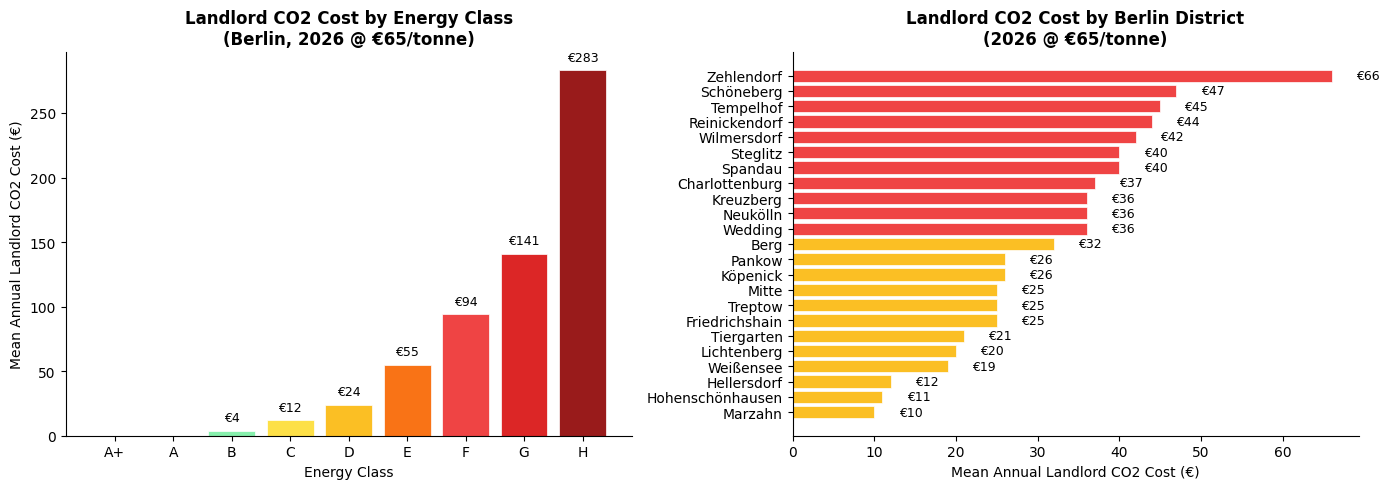

Saved: data/processed/co2_cost_by_class_and_district.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Landlord CO2 cost by energy class ---
ax = axes[0]
class_costs = df.groupby("energy_class", observed=True)["landlord_co2_cost_annual"].agg(["mean", "median"]).round(0)
class_colors = [colors.get(c, "#999") for c in class_costs.index]

bars = ax.bar(class_costs.index.astype(str), class_costs["mean"], color=class_colors, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, class_costs["mean"]):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"€{val:.0f}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Energy Class")
ax.set_ylabel("Mean Annual Landlord CO2 Cost (€)")
ax.set_title("Landlord CO2 Cost by Energy Class\n(Berlin, 2026 @ €65/tonne)", fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

# --- Right: Landlord CO2 cost by district ---
ax = axes[1]
district_costs = df.groupby("bezirk")["landlord_co2_cost_annual"].mean().sort_values(ascending=True).round(0)
bar_colors = ["#ef4444" if v > district_costs.median() else "#fbbf24" for v in district_costs.values]

ax.barh(district_costs.index, district_costs.values, color=bar_colors, edgecolor="white", linewidth=0.5)
for i, (district, val) in enumerate(district_costs.items()):
    ax.text(val + 3, i, f"€{val:.0f}", va="center", fontsize=9)

ax.set_xlabel("Mean Annual Landlord CO2 Cost (€)")
ax.set_title("Landlord CO2 Cost by Berlin District\n(2026 @ €65/tonne)", fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../data/processed/co2_cost_by_class_and_district.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/processed/co2_cost_by_class_and_district.png")

## Step 5: Net Rent Impact — CO2 Cost vs Mietpreisbremse

The real insight: for landlords charging at or near the legal maximum, how much does CO2 cost eat into their net rent? This is the "hidden compliance cost" that nobody shows them.

In [8]:
# Show the combined compliance picture for a typical apartment
print("=" * 60)
print("COMBINED COMPLIANCE PICTURE — Example: 75m² Altbau, gas heating")
print("=" * 60)

# Typical scenario
sqm = 75
thermal_char = 130  # kWh/m²/year (energy class E)
emission_factor = 0.201  # gas
co2_kg = thermal_char * emission_factor  # ~26 kg CO2/m²/year
landlord_share = get_landlord_share(co2_kg)
co2_total = (co2_kg * sqm / 1000) * CO2_PRICE_2026
landlord_co2 = co2_total * (landlord_share / 100)

legal_max = 12.50  # hypothetical Mietpreisbremse max
gross_rent = legal_max * sqm
net_rent = gross_rent - (landlord_co2 / 12)

print(f"\n  Energy consumption:     {thermal_char} kWh/m²/year (Class E)")
print(f"  CO2 emissions:          {co2_kg:.0f} kg CO2/m²/year")
print(f"  Landlord CO2 share:     {landlord_share}%")
print(f"  Annual CO2 cost:        €{co2_total:.0f} total → €{landlord_co2:.0f} landlord")
print(f"  Monthly CO2 cost:       €{landlord_co2/12:.0f}")
print(f"")
print(f"  Legal max rent:         €{legal_max:.2f}/m² → €{gross_rent:.0f}/month gross")
print(f"  After CO2 deduction:    €{net_rent:.0f}/month net")
print(f"  Effective rent loss:    €{landlord_co2/12:.0f}/month = {landlord_co2/12/gross_rent*100:.1f}% of gross rent")
print(f"")
print(f"  ⚡ This is money the landlord loses EVEN IF they charge the legal maximum.")
print(f"     Without RentSignal, most landlords don't know this cost exists.")

# Now show the CO2 price trajectory impact
print(f"\n{'Year':<8} {'CO2 Price':>12} {'Landlord Cost':>15} {'% of Rent':>10}")
print("-" * 48)
for year, price in [(2023, 30), (2024, 45), (2025, 55), (2026, 65), (2027, 75), (2030, 100)]:
    cost = (co2_kg * sqm / 1000) * price * (landlord_share / 100)
    print(f"{year:<8} {'€'+str(price)+'/t':>12} {'€'+f'{cost:.0f}'+'/yr':>15} {cost/12/gross_rent*100:>9.1f}%")

COMBINED COMPLIANCE PICTURE — Example: 75m² Altbau, gas heating

  Energy consumption:     130 kWh/m²/year (Class E)
  CO2 emissions:          26 kg CO2/m²/year
  Landlord CO2 share:     30%
  Annual CO2 cost:        €127 total → €38 landlord
  Monthly CO2 cost:       €3

  Legal max rent:         €12.50/m² → €938/month gross
  After CO2 deduction:    €934/month net
  Effective rent loss:    €3/month = 0.3% of gross rent

  ⚡ This is money the landlord loses EVEN IF they charge the legal maximum.
     Without RentSignal, most landlords don't know this cost exists.

Year        CO2 Price   Landlord Cost  % of Rent
------------------------------------------------
2023            €30/t          €18/yr       0.2%
2024            €45/t          €26/yr       0.2%
2025            €55/t          €32/yr       0.3%
2026            €65/t          €38/yr       0.3%
2027            €75/t          €44/yr       0.4%
2030           €100/t          €59/yr       0.5%


## Step 6: Portfolio-Level Impact

For a property manager with a typical Berlin portfolio, what's the total CO2 cost exposure?

In [9]:
# Portfolio scenarios
print("PORTFOLIO CO2 EXPOSURE SCENARIOS (2026)\n")
print(f"{'Portfolio':<35} {'Units':>6} {'Total CO2 Cost':>15} {'Per Unit':>10}")
print("-" * 70)

avg_cost = df["landlord_co2_cost_annual"].mean()
for name, units in [
    ("Small landlord", 5),
    ("Professional landlord", 20),
    ("Hausverwaltung (small)", 100),
    ("Hausverwaltung (medium)", 500),
    ("Buena-scale", 60000),
]:
    total = avg_cost * units
    print(f"  {name:<33} {units:>6,} {'€'+f'{total:,.0f}':>15} {'€'+f'{avg_cost:.0f}':>10}")

print(f"\n  Average landlord CO2 cost per apartment: €{avg_cost:.0f}/year")
print(f"  Berlin-wide estimate (23M rental apts): €{avg_cost * 23_000_000 / 1_000_000:.0f}M/year")

# Key pitch stat
exposed_pct = (df["landlord_co2_share_pct"] > 0).mean() * 100
high_exposure_pct = (df["landlord_co2_share_pct"] >= 50).mean() * 100
print(f"\n📊 KEY STAT: {exposed_pct:.0f}% of Berlin apartments trigger CO2 cost-sharing.")
print(f"   {high_exposure_pct:.0f}% are in the high-impact zone (landlord pays ≥50%).")
print(f"   Most landlords don't know this cost exists — RentSignal shows it.")

PORTFOLIO CO2 EXPOSURE SCENARIOS (2026)

Portfolio                            Units  Total CO2 Cost   Per Unit
----------------------------------------------------------------------
  Small landlord                         5            €157        €31
  Professional landlord                 20            €627        €31
  Hausverwaltung (small)               100          €3,137        €31
  Hausverwaltung (medium)              500         €15,687        €31
  Buena-scale                       60,000      €1,882,463        €31

  Average landlord CO2 cost per apartment: €31/year
  Berlin-wide estimate (23M rental apts): €722M/year

📊 KEY STAT: 84% of Berlin apartments trigger CO2 cost-sharing.
   10% are in the high-impact zone (landlord pays ≥50%).
   Most landlords don't know this cost exists — RentSignal shows it.
